In [ ]:
# TO INSPECT THE STRUCTURE OF YOUR NETCDF FILE RUN THE FOLLOWING WITH THE CORRECT FILE PATH
# 
!ncdump -h /ADB/original/sentinel6a/JASON_CS_S6A_L2_ALT_LR_STD_OST_NTC_G01/035/S6A_P4_2__LR_STD__NT_035_004_20211020T220949_20211020T230602_G01.nc

netcdf S6A_P4_2__LR_STD__NT_035_004_20211020T220949_20211020T230602_G01 {

// global attributes:
		:Convention = "CF-1.7" ;
		:institution = "EUMETSAT" ;
		:references = "Sentinel-6_Jason-CS ALT Generic Product Format Specification (897975 v6), Sentinel-6_Jason-CS ALT Level 2 Product Format Specification (901187 v5A), Sentinel-6_Jason-CS ALT Level 2 NetCDF Dump (957846 v6)" ;
		:contact = "ops@eumetsat.int" ;
		:radiometer_sensor_name = "AMR-C" ;
		:doris_sensor_name = "DORIS" ;
		:gnss_sensor_name = "GNSS" ;
		:title = "L2 LR Non Time Critical" ;
		:source = "Processing Baseline G01" ;
		:history = "2025-05-30 21:29:10 : Creation" ;
		:mission_name = "Sentinel-6A" ;
		:altimeter_sensor_name = "Poseidon-4B" ;
		:acq_station_name = "Fairbanks" ;
		:netcdf_version = "4.7.0 of Jul 16 2023 05:24:29 $" ;
		:cycle_number = 35 ;
		:pass_number = 4 ;
		:absolute_rev_number = 4269 ;
		:first_measurement_time = "2021-10-20T22:09:49.544409Z" ;
		:last_measurement_time = "2021-10-20T23:06:02.47414

In [26]:
##Load netCDF file and read the variables of intereset based on the nested groups and subgroups structure

from netCDF4 import Dataset

file_path = "/ADB/original/sentinel6a/JASON_CS_S6A_L2_ALT_LR_STD_OST_NTC_G01/035/S6A_P4_2__LR_STD__NT_035_126_20211025T162800_20211025T172413_G01.nc"

# Open the file using the netCDF4 library
try:
    with Dataset(file_path, "r") as ds:
        # Navigate the groups
        grp = ds.groups["data_01"]

        # Pull latitude/longitude from the 'data_01' group 
        lat = grp.variables["latitude"][:]
        lon = grp.variables["longitude"][:]
        
        print("Success! Data loaded.")        
except Exception as e:
    print(f"Error processing file {file_path}: {e}")

Success! Data loaded.


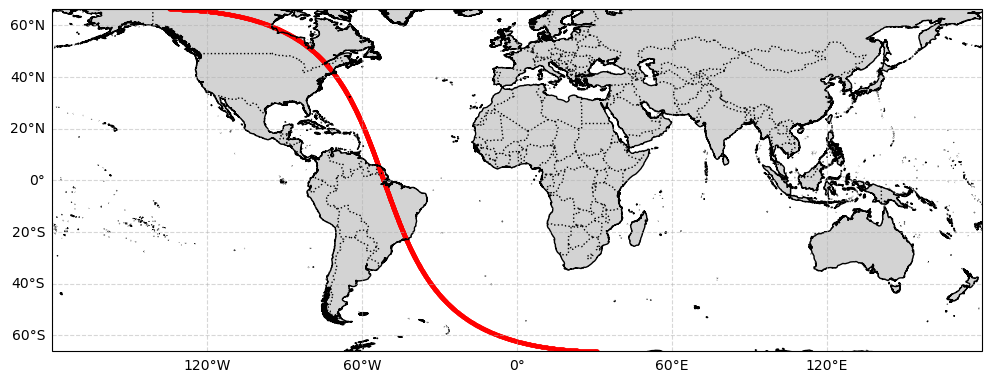

In [ ]:
### Plot the extracted data

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
    
ax.set_extent([min(lon), max(lon), min(lat), max(lat)], crs=ccrs.PlateCarree())
    
# Add geographical references
ax.coastlines(resolution='10m', color='black', linewidth=1)
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.BORDERS, linestyle=':')
    
gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
gl.top_labels = False
gl.right_labels = False

ax.scatter(lon, lat, color="red", s=3, transform=ccrs.PlateCarree(), label="Dati Sentinel-6")
plt.show()

In [ ]:
### Proceed in the 